In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the cleaned dataset

In [3]:
orders = pd.read_csv('/Users/nitesh/Yuva Intern/Task 3/cleaned_orders.csv')

print("Dataset loaded successfully.")
print("Shape:", orders.shape)

Dataset loaded successfully.
Shape: (99441, 16)


#### Checking the target

In [4]:
print("Target variable: actual_delivery_days")
print("\nMissing values:")
print(orders['actual_delivery_days'].isna().sum())

print("\nTarget statistics:")
print(orders['actual_delivery_days'].describe())

Target variable: actual_delivery_days

Missing values:
2965

Target statistics:
count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: actual_delivery_days, dtype: float64


#### Creating modeling dataset

In [5]:
model_data = orders.dropna(
    subset=['actual_delivery_days']
).copy()

print("Modeling dataset shape:", model_data.shape)

Modeling dataset shape: (96476, 16)


#### Selecting valid prediction features

In [9]:
model_data['order_purchase_timestamp'] = pd.to_datetime(
    model_data['order_purchase_timestamp'],
    errors='coerce'
)

model_data['order_estimated_delivery_date'] = pd.to_datetime(
    model_data['order_estimated_delivery_date'],
    errors='coerce'
)

# Calculate estimated delivery duration in days
model_data['estimated_delivery_days'] = (
    model_data['order_estimated_delivery_date']
    - model_data['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

print("Estimated delivery days created successfully.")
print("\nEstimated Delivery Days Statistics:")
print(model_data['estimated_delivery_days'].describe())

Estimated delivery days created successfully.

Estimated Delivery Days Statistics:
count    96476.000000
mean        23.737822
std          8.763466
min          2.008009
25%         18.330014
50%         23.231343
75%         28.408371
max        155.135463
Name: estimated_delivery_days, dtype: float64


In [10]:
features = [
    'purchase_year',
    'purchase_month',
    'estimated_delivery_days'
]

target = 'actual_delivery_days'

X = model_data[features].copy()
y = model_data[target].copy()

print("Selected Features:")
print(features)

print("\nTarget Variable:")
print(target)

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nMissing Values:")
print(X.isnull().sum())
print("\nTarget Missing Values:", y.isnull().sum())

Selected Features:
['purchase_year', 'purchase_month', 'estimated_delivery_days']

Target Variable:
actual_delivery_days

Feature Shape: (96476, 3)
Target Shape: (96476,)

Missing Values:
purchase_year              0
purchase_month             0
estimated_delivery_days    0
dtype: int64

Target Missing Values: 0


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (77180, 3)
y_train: (77180,)

Testing set:
X_test: (19296, 3)
y_test: (19296,)


#### Linear Regression.

In [12]:
from sklearn.linear_model import LinearRegression

# Create and train the model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


#### Evaluate Linear Regression

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("--------------------------------")
print(f"MAE  : {mae_lr:.2f} days")
print(f"RMSE : {rmse_lr:.2f} days")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Performance
--------------------------------
MAE  : 5.66 days
RMSE : 9.33 days
R²   : 0.1307


#### Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [15]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("--------------------------------")
print(f"MAE  : {mae_rf:.2f} days")
print(f"RMSE : {rmse_rf:.2f} days")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
--------------------------------
MAE  : 6.15 days
RMSE : 10.20 days
R²   : -0.0410


#### feature importance from Random Forest.

In [16]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
                   Feature  Importance
2  estimated_delivery_days    0.894252
1           purchase_month    0.082068
0            purchase_year    0.023680


#### Actual vs Predicted Delivery Days

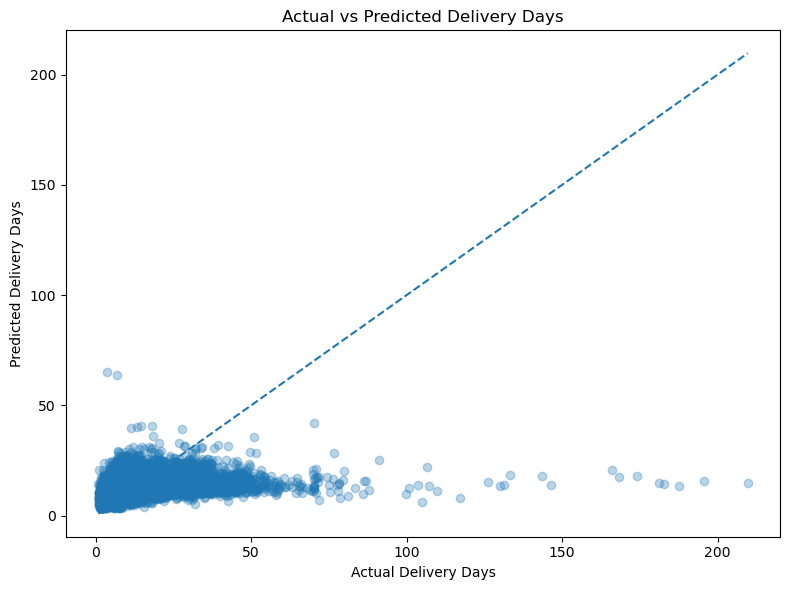

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.3)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred_lr.min())
max_value = max(y_test.max(), y_pred_lr.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel("Actual Delivery Days")
plt.ylabel("Predicted Delivery Days")
plt.title("Actual vs Predicted Delivery Days")

plt.tight_layout()
plt.show()

## Optimization Strategies

The predictive analysis can be used to improve logistics operations by identifying orders that are likely to require longer delivery times. Since the estimated delivery duration was the most important feature in the Random Forest analysis (89.43%), it can be used as an early indicator for delivery planning.

The following optimization strategies are proposed:

1. **Prioritize high-risk orders:** Orders with higher predicted delivery times can be flagged for early intervention and closer monitoring.

2. **Improve resource allocation:** Additional logistics resources, such as delivery capacity and operational support, can be allocated to periods or orders where longer delivery times are expected.

3. **Monitor seasonal patterns:** Monthly late-delivery rates can be monitored to identify periods with unusually high delays and support proactive planning.

4. **Use estimated delivery time as an early-warning indicator:** The estimated delivery duration can be incorporated into operational monitoring to identify potentially delayed orders before delivery.

5. **Investigate extreme delays separately:** Orders with exceptionally long actual delivery times should be investigated individually because they may represent unusual operational problems or data-quality issues.

In [20]:
model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (days)': [5.66, 6.15],
    'RMSE (days)': [9.33, 10.20],
    'R² Score': [0.1307, -0.0410]
})

print("Model Performance Comparison:")
display(model_comparison)

Model Performance Comparison:


,Model,MAE (days),RMSE (days),R² Score
0,Linear Regression,5.66,9.33,0.1307
1,Random Forest,6.15,10.20,-0.0410


## Final Model Conclusion

The two predictive models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

Linear Regression achieved an MAE of 5.66 days, an RMSE of 9.33 days, and an R² score of 0.1307. Random Forest achieved an MAE of 6.15 days, an RMSE of 10.20 days, and an R² score of -0.0410.

Based on these results, Linear Regression performed better than Random Forest for predicting actual delivery time. It produced lower MAE and RMSE values, meaning its predictions were closer to the actual delivery time on average. It also achieved a positive R² score, whereas Random Forest produced a negative R² score.

Therefore, Linear Regression is selected as the final model for this analysis. However, the relatively low R² score indicates that the current features explain only a limited portion of the variation in actual delivery time. This suggests that additional operational factors, such as seller location, customer location, product characteristics, freight value, shipping distance, carrier performance, and order processing time, could improve future model performance.

The model can still provide useful baseline predictions and support logistics teams in identifying orders that may require additional attention.

## Optimization Strategies

The predictive modeling results can be used to support logistics optimization and improve delivery planning. Since Linear Regression was selected as the final model, its delivery-time predictions can be used as a baseline for identifying orders that may require additional operational attention.

The feature-importance analysis from the Random Forest model showed that estimated delivery days was the most influential feature, with an importance of 89.43%. This indicates that the expected delivery duration is strongly associated with the actual delivery time. Therefore, improving the accuracy of estimated delivery dates can be an important area for operational improvement.

### 1. Proactive Delivery Monitoring

Orders with higher predicted delivery times can be flagged for additional monitoring. Logistics teams can review these orders earlier and take corrective action before delays become critical.

### 2. Resource Allocation

Historical delivery patterns and model predictions can support better allocation of logistics resources. Additional operational capacity can be planned during periods where delivery times are expected to increase.

### 3. Improve Estimated Delivery Dates

The strong importance of estimated delivery days suggests that improving estimated delivery-date calculations could help improve customer expectations and operational planning. More accurate estimates can be developed using additional information such as seller performance, customer location, product characteristics, shipping distance, and carrier performance.

### 4. Focus on Additional Predictive Features

The relatively low R² score of the selected model indicates that the current features do not explain a large portion of the variation in actual delivery time. Future models should incorporate additional logistics-related variables to improve prediction accuracy and support more precise operational decisions.

### 5. Continuous Model Monitoring

The prediction model should be periodically evaluated using new delivery data. Changes in delivery patterns, seasonal demand, seller performance, and logistics conditions can affect model performance. Regular monitoring and retraining can help maintain reliable predictions.

## Final Recommendations

Based on the predictive modeling results, Linear Regression was selected as the final model because it achieved better MAE, RMSE, and R² performance than Random Forest.

The model can be used as a baseline for delivery-time prediction and operational planning. Predicted delivery times can help logistics teams identify orders that may require additional monitoring and prioritize operational attention.

The analysis also showed that estimated delivery days was the most influential feature in the Random Forest model. Improving the accuracy of estimated delivery dates can therefore support better planning and customer expectations.

For future model improvement, additional logistics-related features such as shipping distance, seller performance, customer location, product characteristics, freight information, and carrier performance should be incorporated. These variables may provide additional information for explaining delivery-time variation and improving prediction accuracy.

Regular model evaluation and retraining should also be performed as new delivery data becomes available. This can help maintain model reliability as logistics patterns and operational conditions change.